# XAUUSD LLM Forecaster — Colab Pipeline

**Before running:**
1. Runtime → Change runtime type → **GPU** (T4 or better)
2. Run all cells top-to-bottom — no uploads needed, everything is in the repo.

## 0. Setup — Mount Drive, Install Dependencies

In [1]:
import os, sys

REPO_URL = 'https://github.com/211abhi/xauusd-llm-forecaster.git'
CODE_DIR = '/content/xauusd-llm-forecaster'

if not os.path.isdir(CODE_DIR):
    !git clone {REPO_URL} {CODE_DIR}
else:
    !git -C {CODE_DIR} pull

# Use %cd so cwd persists for all subsequent !python calls
%cd {CODE_DIR}
sys.path.insert(0, CODE_DIR)
os.environ['PYTHONPATH'] = CODE_DIR

for d in ['data/raw', 'data/processed', 'data/splits',
          'checkpoints/encoder', 'checkpoints/soft_prompt', 'checkpoints/pred_head',
          'logs']:
    os.makedirs(os.path.join(CODE_DIR, d), exist_ok=True)

print(f'Working directory: {os.getcwd()}')

Cloning into '/content/xauusd-llm-forecaster'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 96 (delta 29), reused 81 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 3.56 MiB | 7.95 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/xauusd-llm-forecaster
Working directory: /content/xauusd-llm-forecaster


In [2]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q transformers>=4.40.0 datasets ta cma scikit-learn pyyaml tqdm matplotlib seaborn

In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
import yaml, os

CODE_DIR = '/content/xauusd-llm-forecaster'

cfg = {
    'project': {
        'name': 'xauusd-llm-forecaster',
        'seed': 42,
        'device': device,
        'log_dir': f'{CODE_DIR}/logs/',
        'checkpoint_dir': f'{CODE_DIR}/checkpoints/',
    },
    'data': {
        'raw_path': f'{CODE_DIR}/data/raw/XAU_30m_data.csv',
        'processed_dir': f'{CODE_DIR}/data/processed/',
        'splits_dir': f'{CODE_DIR}/data/splits/',
        'datetime_col': 'datetime',
        'feature_cols': ['open', 'high', 'low', 'close', 'volume'],
        'derived_features': ['returns', 'log_returns', 'hl_range', 'body_ratio'],
        'indicators': {'atr_period': 14, 'rsi_period': 14, 'ema_fast': 20, 'ema_slow': 50},
        'split_ratios': {'train': 0.70, 'val': 0.15, 'test': 0.15},
        'normalization': 'rolling_minmax',
        'norm_window': 500,
    },
    'regime_labeling': {
        'rsi_high': 55, 'rsi_low': 45, 'rsi_mid_low': 40, 'rsi_mid_high': 60,
        'ranging_atr_mult': 0.3, 'atr_spike_mult': 1.5, 'hl_range_spike_mult': 1.5,
        'breakout_lookback': 20, 'volume_spike_mult': 1.5,
    },
    'tokenizer': {
        'window_size': 96, 'patch_size': 16, 'n_patches': 6,
        'n_features': 9, 'patch_dim': 144,
        'train_stride': 1, 'val_stride': 8,
    },
    'encoder': {
        'embed_dim': 256, 'n_heads': 8, 'n_layers': 4, 'ffn_dim': 512,
        'dropout': 0.1, 'max_seq_len': 7, 'output_dim': 256,
        'checkpoint_path': f'{CODE_DIR}/checkpoints/encoder/best_encoder.pt',
    },
    'alignment': {
        'temperature': 0.07,
        'projection_dim': 1024,
        'n_regimes': 5,
        'regime_labels': ['TRENDING_UP', 'TRENDING_DOWN', 'RANGING', 'VOLATILE', 'BREAKOUT'],
        'n_negatives': 4,
    },
    'encoder_training': {
        'epochs': 20, 'batch_size': 64, 'lr': 1e-4, 'weight_decay': 1e-5,
        'warmup_steps': 200, 'lr_schedule': 'cosine', 'patience': 10, 'val_every': 1,
    },
    'llm': {
        'model_name': 'gpt2-medium',
        'hidden_dim': 1024,
        'freeze_all': True,
        'hidden_state_layer': -1, 'hidden_state_position': 0,
        'cache_dir': f'{CODE_DIR}/.cache/llm',
    },
    'soft_prompt': {
        'n_tokens': 32,
        'token_dim': 1024,
        'init_std': 0.01,
        'checkpoint_path': f'{CODE_DIR}/checkpoints/soft_prompt/best_soft_prompt.npy',
    },
    'cmaes': {
        'subspace_dim': 500, 'popsize': 20, 'sigma0': 0.1, 'maxiter': 300,
        'early_stop_patience': 50, 'fitness_metric': 'val_mae', 'eval_batch_size': 32,
    },
    'prediction_head': {
        'input_dim': 1024,
        'hidden_dim': 256, 'output_steps': 8, 'dropout': 0.1,
        'checkpoint_path': f'{CODE_DIR}/checkpoints/pred_head/best_pred_head.pt',
    },
    'pred_head_training': {
        'epochs': 30, 'batch_size': 32, 'lr': 1e-3, 'weight_decay': 1e-5,
        'patience': 10, 'loss': 'mse',
    },
    'evaluation': {
        'metrics': ['mae', 'rmse', 'directional_accuracy'],
        'per_regime': True, 'rolling_window_months': 1,
    },
}

cfg_path = f'{CODE_DIR}/configs/base_config.yaml'
os.makedirs(os.path.dirname(cfg_path), exist_ok=True)
with open(cfg_path, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print(f'Config written → {cfg_path}')
print(f'  device        : {device}')
print(f'  encoder epochs: {cfg["encoder_training"]["epochs"]}')
print(f'  llm hidden_dim: {cfg["llm"]["hidden_dim"]}')

Config written → /content/xauusd-llm-forecaster/configs/base_config.yaml
  device        : cuda
  encoder epochs: 20
  llm hidden_dim: 1024


## Phase 1 — Data Preparation

Cleans raw OHLCV, adds indicators, normalizes, and saves train/val/test splits.

In [5]:
!python {CODE_DIR}/scripts/01_prepare_data.py --config {CODE_DIR}/configs/base_config.yaml

Loading raw data...
  248912 rows loaded, date range: 2004-06-11 07:00:00 → 2026-01-30 23:30:00
Forward-filling gaps...
  379378 rows after gap fill
Adding derived features...
Adding technical indicators...
  379378 rows after indicator warmup drop
Computing normalization stats on train split only...
Applying normalization...
Saved processed data → /content/xauusd-llm-forecaster/data/processed/xau_processed.csv
Saved normalization stats → /content/xauusd-llm-forecaster/data/processed/norm_stats.json
Saving split indices...
Saved split indices → /content/xauusd-llm-forecaster/data/splits/
Split sizes: train=265564, val=56907, test=56907
Phase 1 complete.


In [6]:
# Quick sanity check
import pandas as pd
df = pd.read_csv('data/processed/xau_processed.csv', parse_dates=['datetime'])
print(f'Processed rows: {len(df)}')
print(df.describe().round(3))

Processed rows: 379378
                            datetime        open        high         low  \
count                         379378  379378.000  379378.000  379378.000   
mean   2015-04-07 03:15:00.000001280       0.610       0.610       0.611   
min              2004-06-11 07:00:00       0.000       0.000       0.000   
25%              2009-11-08 05:07:30       0.442       0.442       0.443   
50%              2015-04-07 03:15:00       0.599       0.599       0.600   
75%              2020-09-03 01:22:30       0.891       0.891       0.892   
max              2026-01-30 23:30:00       1.000       1.000       1.000   
std                              NaN       0.299       0.299       0.299   

            close      volume     returns  log_returns    hl_range  \
count  379378.000  379378.000  379378.000   379378.000  379378.000   
mean        0.610       0.032       0.479        0.488       2.361   
min         0.000       0.000       0.000        0.000       0.000   
25%         

## Phase 1b — Regime Labeling

Assigns rule-based market regime labels (TRENDING_UP / DOWN / RANGING / VOLATILE / BREAKOUT).

In [7]:
!python {CODE_DIR}/scripts/02_label_regimes.py --config {CODE_DIR}/configs/base_config.yaml

Loaded 379378 rows from processed data
Labeling market regimes...
  Regime distribution (per-candle):
    BREAKOUT       :  32389 (8.5%)
    TRENDING_DOWN  : 287973 (75.9%)
    VOLATILE       :  59016 (15.6%)
Saved → /content/xauusd-llm-forecaster/data/processed/xau_with_regimes.csv

  train window regimes (265469 windows):
    TRENDING_DOWN  : 252673
    VOLATILE       : 12796

  val window regimes (7102 windows):
    TRENDING_DOWN  : 5651
    VOLATILE       : 1451

  test window regimes (7102 windows):
    TRENDING_DOWN  : 3914
    VOLATILE       : 3188

Phase 1b complete.


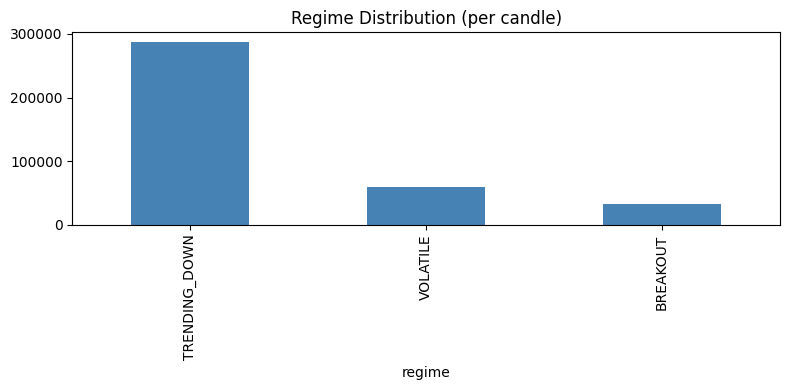

regime
TRENDING_DOWN    287973
VOLATILE          59016
BREAKOUT          32389
Name: count, dtype: int64


In [8]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv('data/processed/xau_with_regimes.csv', parse_dates=['datetime'])
counts = df['regime'].value_counts()
counts.plot(kind='bar', figsize=(8, 4), title='Regime Distribution (per candle)', color='steelblue')
plt.tight_layout()
plt.show()
print(counts)

## Phase 2 — Train TS Encoder (Contrastive)

Trains the 1D-Conv + Transformer encoder against frozen LLM text embeddings via InfoNCE loss.

⏱ ~20–40 min on T4 depending on dataset size.

In [9]:
!python {CODE_DIR}/scripts/03_train_encoder.py --config {CODE_DIR}/configs/base_config.yaml

Loading processed data...
Building patch arrays...
  train patches: (265469, 6, 144), val patches: (7102, 6, 144)
Precomputing regime text embeddings (frozen LLM)...
config.json: 100% 718/718 [00:00<00:00, 2.54MB/s]
tokenizer_config.json: 100% 26.0/26.0 [00:00<00:00, 112kB/s]
vocab.json: 1.04MB [00:00, 20.7MB/s]
merges.txt: 456kB [00:00, 3.91MB/s]
tokenizer.json: 1.36MB [00:00, 6.92MB/s]
model.safetensors: 100% 1.52G/1.52G [00:11<00:00, 131MB/s]
Loading weights: 100% 292/292 [00:00<00:00, 1115.55it/s, Materializing param=wte.weight]
GPT2Model LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  Computed embeddings for 5 regimes
  Regime counts (train): {'TRENDING_DOWN': 252673, 'VOLATILE': 12796}
Building encoder + projection head...
Starting contrastive training...
Epo

In [10]:
from pathlib import Path
CODE_DIR = '/content/xauusd-llm-forecaster'
ckpt = Path(f'{CODE_DIR}/checkpoints/encoder/best_encoder.pt')
print('Encoder checkpoint saved:', ckpt.exists())
if ckpt.exists():
    print(f'Size: {ckpt.stat().st_size / 1e6:.1f} MB')

Encoder checkpoint saved: True
Size: 13.9 MB


In [11]:
# Save encoder checkpoint to GitHub so you never need to retrain
# Paste a GitHub Personal Access Token (Settings → Developer settings → PAT → classic, repo scope)
from getpass import getpass
from pathlib import Path

ckpt = Path(f'{CODE_DIR}/checkpoints/encoder/best_encoder.pt')
if ckpt.exists():
    token = getpass('GitHub PAT (hidden): ')
    !git -C {CODE_DIR} config user.email "colab@train"
    !git -C {CODE_DIR} config user.name "Colab"
    !git -C {CODE_DIR} remote set-url origin https://{token}@github.com/211abhi/xauusd-llm-forecaster.git
    !git -C {CODE_DIR} add checkpoints/encoder/best_encoder.pt
    !git -C {CODE_DIR} commit -m "Add trained encoder checkpoint"
    !git -C {CODE_DIR} push origin main
    print('Encoder checkpoint pushed to GitHub.')
else:
    print('No checkpoint found — training may have failed.')

GitHub PAT (hidden): ··········
The following paths are ignored by one of your .gitignore files:
checkpoints
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   configs/base_config.yaml

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	=4.40.0

no changes added to commit (use "git add" and/or "git commit -a")
Everything up-to-date
Encoder checkpoint pushed to GitHub.


## Phase 3 — CMA-ES Soft Prompt Optimization

Optimizes the (32, 768) soft prompt prefix in a 500-dim subspace using evolutionary search.

⏱ ~1–3 hours on T4 (300 generations × 20 candidates). Reduce `maxiter` in config to speed up.

**To speed up:** Edit `configs/base_config.yaml` → `cmaes.maxiter: 50` for a quick test run.

In [ ]:
!python {CODE_DIR}/scripts/04_optimize_soft_prompt.py --config {CODE_DIR}/configs/base_config.yaml

Loading frozen encoder...
Loading frozen LLM...
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100% 292/292 [00:00<00:00, 1046.08it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
generation_config.json: 100% 124/124 [00:00<00:00, 552kB/s]
Initializing soft prompt and prediction head...
Starting CMA-ES optimization...


In [ ]:
import numpy as np
from pathlib import Path
CODE_DIR = '/content/xauusd-llm-forecaster'
sp_path = Path(f'{CODE_DIR}/checkpoints/soft_prompt/best_soft_prompt.npy')
print('Soft prompt saved:', sp_path.exists())
if sp_path.exists():
    arr = np.load(str(sp_path))
    print(f'Shape: {arr.shape}  mean={arr.mean():.4f}  std={arr.std():.4f}')

## Phase 4 — Train Prediction Head

Trains only the 2-layer MLP on frozen encoder + frozen LLM + frozen soft prompt.

⏱ ~5–15 min on T4.

In [ ]:
!python {CODE_DIR}/scripts/05_train_pred_head.py --config {CODE_DIR}/configs/base_config.yaml

In [ ]:
from pathlib import Path
CODE_DIR = '/content/xauusd-llm-forecaster'
ph_path = Path(f'{CODE_DIR}/checkpoints/pred_head/best_pred_head.pt')
print('Pred head saved:', ph_path.exists())

## Phase 5 — Evaluation

Runs the full pipeline on the held-out test set and reports MAE, RMSE, and directional accuracy.

In [ ]:
!python {CODE_DIR}/scripts/06_evaluate.py --config {CODE_DIR}/configs/base_config.yaml

In [ ]:
import json
CODE_DIR = '/content/xauusd-llm-forecaster'
with open(f'{CODE_DIR}/logs/evaluation_results.json') as f:
    results = json.load(f)

print('=== Overall ===')
for k, v in results['overall'].items():
    print(f'  {k}: {v:.4f}')

if 'per_regime' in results:
    print('\n=== Per Regime ===')
    for regime, m in sorted(results['per_regime'].items()):
        print(f"  {regime:15s}  MAE={m['mae']:.4f}  DirAcc={m['directional_accuracy']:.1f}%")

## Quick Inference — Single Prediction

Run this after all phases are complete to test the forecaster on a single window.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from src.prediction.forecaster import Forecaster
from src.utils.data_loader import get_feature_columns

with open('configs/base_config.yaml') as f:
    cfg = yaml.safe_load(f)

forecaster = Forecaster.from_config(cfg)

df = pd.read_csv('data/processed/xau_with_regimes.csv', parse_dates=['datetime'])
feature_cols = get_feature_columns(cfg)
arr = df[feature_cols].values

W = cfg['tokenizer']['window_size']
# Take the last window before the test set
window = arr[-W - 8: -8][np.newaxis]   # (1, W, F)
actual = arr[-8:, feature_cols.index('close')]  # 8 actual future closes

preds = forecaster.predict(window)[0]  # (8,)

plt.figure(figsize=(10, 4))
plt.plot(range(8), actual, 'o-', label='Actual', color='steelblue')
plt.plot(range(8), preds,  's--', label='Predicted', color='tomato')
plt.title('8-Step Ahead Forecast (normalized close price)')
plt.xlabel('Step (×30 min)')
plt.legend()
plt.tight_layout()
plt.show()

mae = abs(preds - actual).mean()
print(f'MAE on this window: {mae:.4f}')

## Save Checkpoints
Download trained weights before the session ends.

In [ ]:
import zipfile, os
from google.colab import files
CODE_DIR = '/content/xauusd-llm-forecaster'

zip_path = '/content/checkpoints.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for root, _, filenames in os.walk(f'{CODE_DIR}/checkpoints'):
        for fname in filenames:
            fpath = os.path.join(root, fname)
            zf.write(fpath, os.path.relpath(fpath, CODE_DIR))

print(f'Zipped checkpoints → {zip_path}')
files.download(zip_path)